### 0 操作准备


In [816]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [817]:
import os
print(os.getcwd())

f:\CTH-MPDSD\Year 2-period 2\ACEX35\Codes\rf_demo\notebooks


In [818]:
# Use a single source dataframe (ms)
ms = pd.read_csv("../data/MT_UPDATE_MS_HEV.csv")
pf_ms = ms.copy()
pf_ms.head()


,fid,MS_ID,Per_extent,Tem_extent,Street_type_NOR,ARw500re,ARw500dn,ARw500rm,Resident_NOR,DayNight_NOR,...,TFAB2k_lossR,N_TFAB2k_lossR,TFAB2k_NOR,TFAB5k_lossR,N_TFAB5k_lossR,TFAB5k_NOR,TF_Index_centrality,TF_Index_V_equal,PF_Index_Risk_equal,TF_Index_Risk_equal
0,142,142,0,0,1.0,0,0,0,0.0,0.0,...,1.285198e-07,1.285198e-07,1.285198e-07,8.135848e-08,8.135848e-08,8.135848e-08,1.049391e-07,2.623478e-08,1.053386e-06,2.623478e-08
1,143,143,0,0,1.0,0,0,0,0.0,0.0,...,6.418516e-08,6.418516e-08,6.418516e-08,-8.140038e-08,8.140038e-08,8.140038e-08,7.279277e-08,1.819819e-08,7.609767e-07,1.819819e-08
2,144,144,0,0,1.0,0,0,0,0.0,0.0,...,1.260546e-07,1.260546e-07,1.260546e-07,0.000000e+00,0.000000e+00,0.000000e+00,6.302730e-08,1.575683e-08,5.071298e-07,1.575683e-08
3,145,145,0,0,1.0,0,0,0,0.0,0.0,...,-1.234763e-07,1.234763e-07,1.234763e-07,0.000000e+00,0.000000e+00,0.000000e+00,6.173816e-08,1.543454e-08,2.705325e-07,1.543454e-08
4,146,146,0,0,1.0,0,0,0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.558391e-09,0.000000e+00


In [819]:
print(ms.dtypes)

fid                      int64
MS_ID                    int64
Per_extent               int64
Tem_extent               int64
Street_type_NOR        float64
                        ...   
TFAB5k_NOR             float64
TF_Index_centrality    float64
TF_Index_V_equal       float64
PF_Index_Risk_equal    float64
TF_Index_Risk_equal    float64
Length: 73, dtype: object


### 1 风险指数阈值探索


1.1 查看风险指标字段与基本统计


In [820]:
pf_index_risk_equal = "PF_Index_Risk_equal"   # 目标风险指数字段

print("Column name:", pf_index_risk_equal)
print("Missing values:", ms[pf_index_risk_equal].isna().sum())
print("Min:", ms[pf_index_risk_equal].min())
print("Max:", ms[pf_index_risk_equal].max())
print("Mean:", ms[pf_index_risk_equal].mean())
print("Median:", ms[pf_index_risk_equal].median())

ms[pf_index_risk_equal].describe()

Column name: PF_Index_Risk_equal
Missing values: 0
Min: 0.0
Max: 0.911250360838595
Mean: 0.02096308497388563
Median: 0.000212991726307


count    1.169590e+05
mean     2.096308e-02
std      7.247937e-02
min      0.000000e+00
25%      8.585538e-09
50%      2.129917e-04
75%      4.134612e-03
max      9.112504e-01
Name: PF_Index_Risk_equal, dtype: float64

1.2 绘制风险指数分布


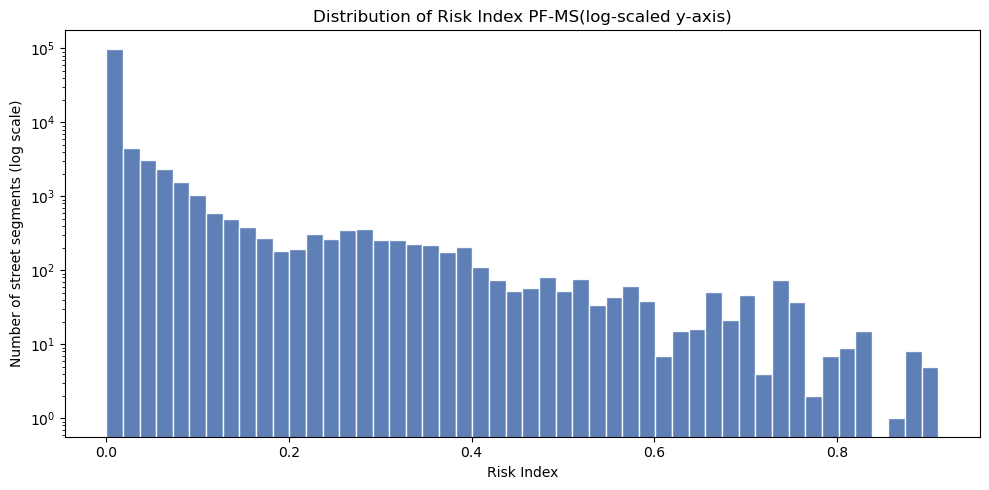

In [821]:
plot_s = pd.to_numeric(ms[pf_index_risk_equal], errors="coerce").dropna()

plt.figure(figsize=(10, 5))
plt.hist(plot_s, bins=50, color="#4C72B0", edgecolor="white", alpha=0.9)

# 对 y 轴（Number of street segments）做对数化
plt.yscale("log")

plt.xlabel("Risk Index")
plt.ylabel("Number of street segments (log scale)")
plt.title("Distribution of Risk Index PF-MS(log-scaled y-axis)")
plt.tight_layout()
plt.show()


1.3 不同阈值下高风险占比


In [822]:
thresholds = [0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6]

summary = []
total_n = len(ms)

for t in thresholds:
    n = (ms[pf_index_risk_equal] > t).sum()
    pct = n / total_n * 100
    summary.append({
        "threshold": t,
        "count_above_threshold": n,
        "percentage_above_threshold": round(pct, 2)
    })

threshold_summary = pd.DataFrame(summary)
threshold_summary

,threshold,count_above_threshold,percentage_above_threshold
0,0.10,6199,5.30
1,0.15,4561,3.90
2,0.20,3840,3.28
3,0.30,2202,1.88
4,0.40,1003,0.86
5,0.50,593,0.51
6,0.60,320,0.27


In [823]:
ms[pf_index_risk_equal].quantile([0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.98, 0.99])

0.50    0.000213
0.70    0.002382
0.80    0.008366
0.85    0.020561
0.90    0.048327
0.95    0.106853
0.98    0.291511
0.99    0.386987
Name: PF_Index_Risk_equal, dtype: float64

In [824]:
thresholds = [0.20, 0.22, 0.24, 0.25, 0.26, 0.28, 0.30]

summary = []
total_n = len(ms)

for t in thresholds:
    n = (ms[pf_index_risk_equal] > t).sum()
    pct = n / total_n * 100
    summary.append({
        "threshold": t,
        "count_above_threshold": n,
        "percentage_above_threshold": round(pct, 2)
    })

threshold_summary = pd.DataFrame(summary)
threshold_summary

,threshold,count_above_threshold,percentage_above_threshold
0,0.20,3840,3.28
1,0.22,3628,3.10
2,0.24,3271,2.80
3,0.25,3130,2.68
4,0.26,2971,2.54
5,0.28,2561,2.19
6,0.30,2202,1.88


### 2 高风险样本筛选与特征整理


2.1 主表字段检查


In [825]:
# Single-source workflow: use ms only
pf_ms = ms.copy()

print("MS_ID in ms:", "MS_ID" in ms.columns)
print("fid in ms:", "fid" in ms.columns)
print("MS_ID unique in ms:", ms["MS_ID"].nunique())
print("pf_ms shape:", pf_ms.shape)


MS_ID in ms: True
fid in ms: True
MS_ID unique in ms: 116959
pf_ms shape: (116959, 73)


In [826]:
# Validate required columns directly in ms (no extra merge)
new_cols = [
    "N_PFlossR_2kiw",
    "N_PFlossR_2ktw",
    "N_PFlossR_2kmw"
]

pf_ms = ms.copy()
missing = [c for c in new_cols if c not in pf_ms.columns]
if missing:
    raise KeyError(f"Missing required columns in ms: {missing}")

print("Original ms shape:", ms.shape)
print("pf_ms shape:", pf_ms.shape)
print(pf_ms[new_cols].isna().sum())

pf_ms[["MS_ID"] + new_cols].head()
pf_ms.head()


Original ms shape: (116959, 73)
pf_ms shape: (116959, 73)
N_PFlossR_2kiw    72098
N_PFlossR_2ktw     4522
N_PFlossR_2kmw    22635
dtype: int64


,fid,MS_ID,Per_extent,Tem_extent,Street_type_NOR,ARw500re,ARw500dn,ARw500rm,Resident_NOR,DayNight_NOR,...,TFAB2k_lossR,N_TFAB2k_lossR,TFAB2k_NOR,TFAB5k_lossR,N_TFAB5k_lossR,TFAB5k_NOR,TF_Index_centrality,TF_Index_V_equal,PF_Index_Risk_equal,TF_Index_Risk_equal
0,142,142,0,0,1.0,0,0,0,0.0,0.0,...,1.285198e-07,1.285198e-07,1.285198e-07,8.135848e-08,8.135848e-08,8.135848e-08,1.049391e-07,2.623478e-08,1.053386e-06,2.623478e-08
1,143,143,0,0,1.0,0,0,0,0.0,0.0,...,6.418516e-08,6.418516e-08,6.418516e-08,-8.140038e-08,8.140038e-08,8.140038e-08,7.279277e-08,1.819819e-08,7.609767e-07,1.819819e-08
2,144,144,0,0,1.0,0,0,0,0.0,0.0,...,1.260546e-07,1.260546e-07,1.260546e-07,0.000000e+00,0.000000e+00,0.000000e+00,6.302730e-08,1.575683e-08,5.071298e-07,1.575683e-08
3,145,145,0,0,1.0,0,0,0,0.0,0.0,...,-1.234763e-07,1.234763e-07,1.234763e-07,0.000000e+00,0.000000e+00,0.000000e+00,6.173816e-08,1.543454e-08,2.705325e-07,1.543454e-08
4,146,146,0,0,1.0,0,0,0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.558391e-09,0.000000e+00


2.2 以 risk index = 0.25 筛选高风险路段


In [827]:

threshold = 0.25
label_threshold = 0.28    # 标签构建使用的更严阈值
risk_col = "PF_Index_Risk_equal"

high_risk_pf_ms = pf_ms[pf_ms[risk_col] > threshold].copy()

print("Training threshold:", threshold)
print("Number of high-risk MS streets:", len(high_risk_pf_ms))
print("Percentage of all MS streets:", round(len(high_risk_pf_ms) / len(ms) * 100, 2), "%")

high_risk_pf_ms.columns.tolist()
high_risk_pf_ms.dtypes.sort_index()
high_risk_pf_ms.head()

Training threshold: 0.25
Number of high-risk MS streets: 3130
Percentage of all MS streets: 2.68 %


,fid,MS_ID,Per_extent,Tem_extent,Street_type_NOR,ARw500re,ARw500dn,ARw500rm,Resident_NOR,DayNight_NOR,...,TFAB2k_lossR,N_TFAB2k_lossR,TFAB2k_NOR,TFAB5k_lossR,N_TFAB5k_lossR,TFAB5k_NOR,TF_Index_centrality,TF_Index_V_equal,PF_Index_Risk_equal,TF_Index_Risk_equal
3753,24341,24341,0,0,0.75,163,118,49,0.549144,0.473397,...,-0.003063,0.003063,0.002297,-0.166727,0.166727,0.125045,0.063671,0.024245,0.626756,0.024245
3754,24342,24342,1,0,0.75,163,118,49,0.549144,0.473397,...,-0.003083,0.003083,0.002312,-0.167125,0.167125,0.125344,0.063828,0.024002,0.813188,0.024002
3755,24343,24343,1,0,0.75,190,118,49,0.565555,0.473397,...,-0.003129,0.003129,0.002347,-0.167538,0.167538,0.125653,0.064000,0.024805,0.814555,0.024805
3756,24344,24344,0,0,0.75,383,118,49,0.640754,0.473397,...,-0.003161,0.003161,0.002371,-0.169138,0.169138,0.126854,0.064612,0.022563,0.557664,0.022563
3757,24345,24345,0,0,0.75,383,118,49,0.640754,0.473397,...,-0.003174,0.003174,0.002381,-0.169463,0.169463,0.127097,0.064739,0.021773,0.556717,0.021773


In [828]:
meta_cols = [col for col in ["fid", "MS_ID", risk_col] if col in high_risk_pf_ms.columns] # join back to QGIS
meta_pf_ms = high_risk_pf_ms[meta_cols].copy()

meta_pf_ms.head()

,fid,MS_ID,PF_Index_Risk_equal
3753,24341,24341,0.626756
3754,24342,24342,0.813188
3755,24343,24343,0.814555
3756,24344,24344,0.557664
3757,24345,24345,0.556717


In [829]:
for col in high_risk_pf_ms.columns:
    print(col)

fid
MS_ID
Per_extent
Tem_extent
Street_type_NOR
ARw500re
ARw500dn
ARw500rm
Resident_NOR
DayNight_NOR
PRM_NOR
Index_population
ABw2kwl
ABw5kwl
ARw2kiw
ARw2ktw
ARw2kmw
PFARw2kiw
PFlossR_2kiw
N_PFlossR_2kiw
PFARw2ktw
PFlossR_2ktw
N_PFlossR_2ktw
PFARw2kmw
PFlossR_2kmw
N_PFlossR_2kmw
PF_Index_acc_loss
PFARw500re
PFARw500dn
PFARw500rm
PFResident_lossR
PFDaynight_lossR
PFPRM_lossR
PF_Index_population
PFABw2kwl
PFABw5kwl
PFAB2k_lossR
N_PFAB2k_lossR
PFAB2k_NOR
PFAB5k_lossR
N_PFAB5k_lossR
PFAB5k_NOR
PF_Index_centrality
PF_Index_V_equal
TFARw2kiw
TFlossR_2kiw
N_TFlossR_2kiw
TFARw2ktw
TFlossR_2ktw
N_TFlossR_2ktw
TFARw2kmw
TFlossR_2kmw
N_TFlossR_2kmw
TF_Index_acc_loss
TFARw500re
TFARw500dn
TFARw500rm
TFResident_lossR
TFDaynight_lossR
TFPRM_lossR
TF_Index_population
TFABw2kwl
TFABw5kwl
TFAB2k_lossR
N_TFAB2k_lossR
TFAB2k_NOR
TFAB5k_lossR
N_TFAB5k_lossR
TFAB5k_NOR
TF_Index_centrality
TF_Index_V_equal
PF_Index_Risk_equal
TF_Index_Risk_equal


2.3 提取核心指标特征


In [830]:
pf_simple_cols = [
    "PF_Index_population",
    "PF_Index_acc_loss",
    "PF_Index_centrality",
    "Per_extent",
]

pf_simple_cols = [col for col in pf_simple_cols if col in high_risk_pf_ms.columns]

print("Simple feature columns:")
print(pf_simple_cols)

X_simple_pf_ms = high_risk_pf_ms[pf_simple_cols].copy()

print("X_simple shape:", X_simple_pf_ms.shape)
X_simple_pf_ms.head()

Simple feature columns:
['PF_Index_population', 'PF_Index_acc_loss', 'PF_Index_centrality', 'Per_extent']
X_simple shape: (3130, 4)


,PF_Index_population,PF_Index_acc_loss,PF_Index_centrality,Per_extent
3753,0.335167,0.710928,0.750000,0
3754,0.502751,1.000000,0.750000,1
3755,0.508221,1.000000,0.750000,1
3756,0.075654,0.702502,0.750000,0
3757,0.075654,0.701362,0.748492,0


In [831]:
print("Missing values in X_simple:")
print(X_simple_pf_ms.isna().sum())

constant_cols_simple_pf_ms = [col for col in X_simple_pf_ms.columns if X_simple_pf_ms[col].nunique() <= 1]
print("Constant columns in X_simple:", constant_cols_simple_pf_ms)

Missing values in X_simple:
PF_Index_population    0
PF_Index_acc_loss      0
PF_Index_centrality    0
Per_extent             0
dtype: int64
Constant columns in X_simple: []


In [832]:
X_simple_pf_ms.to_csv("../data/X_simple_pf_ms_0_25.csv", index=False)
meta_pf_ms.to_csv("../data/meta_pf_ms_0_25.csv", index=False)

2.4 提取人口结构细分指标


In [833]:
population_detail_cols = ["PFResident_NOR",
                          "PFDaynight_NOR", 
                          "PFPRM_NOR"
]

acc_loss_detail_cols_pf = [
"N_PFlossR_2kiw", 
"N_PFlossR_2ktw", 
"N_PFlossR_2kmw"
]

structure_cols = [
    "PF_Index_centrality",
    "Per_extent",
]

structure_cols = [col for col in structure_cols if col in high_risk_pf_ms.columns]
population_detail_cols = [col for col in population_detail_cols if col in high_risk_pf_ms.columns]
acc_loss_detail_cols_pf = [col for col in acc_loss_detail_cols_pf if col in high_risk_pf_ms.columns]

detailed_feature_cols_pf = population_detail_cols + acc_loss_detail_cols_pf + structure_cols

print("Detailed feature columns:")
print(detailed_feature_cols_pf)

X_detailed_pf_ms = high_risk_pf_ms[detailed_feature_cols_pf].copy()

print("X_detailed shape:", X_detailed_pf_ms.shape)
X_detailed_pf_ms.head()

Detailed feature columns:
['N_PFlossR_2kiw', 'N_PFlossR_2ktw', 'N_PFlossR_2kmw', 'PF_Index_centrality', 'Per_extent']
X_detailed shape: (3130, 5)


,N_PFlossR_2kiw,N_PFlossR_2ktw,N_PFlossR_2kmw,PF_Index_centrality,Per_extent
3753,-0.833333,-0.716794,-0.582656,0.750000,0
3754,1.000000,1.000000,1.000000,0.750000,1
3755,1.000000,1.000000,1.000000,0.750000,1
3756,-1.000000,-0.486219,-0.621287,0.750000,0
3757,-1.000000,-0.486219,-0.617866,0.748492,0


In [834]:
print("Missing values in X_detailed:")
print(X_detailed_pf_ms.isna().sum().sort_values(ascending=False))

constant_cols_detailed_pf_ms = [col for col in X_detailed_pf_ms.columns if X_detailed_pf_ms[col].nunique() <= 1]
print("Constant columns in X_detailed:", constant_cols_detailed_pf_ms)

Missing values in X_detailed:
N_PFlossR_2kiw         777
N_PFlossR_2kmw         217
N_PFlossR_2ktw           0
PF_Index_centrality      0
Per_extent               0
dtype: int64
Constant columns in X_detailed: []


In [835]:
# 阈值：0.15

label_pf_ms = pf_ms[pf_ms[risk_col] > label_threshold].copy()


### 3 干预类型规则标注与建模


3.1 规则标签构建


3.1.1 三档分层规则


In [836]:
col = "PF_Index_centrality"

print("col in df:", col in high_risk_pf_ms.columns)
print("similar cols:", [c for c in high_risk_pf_ms.columns if "centrality" in c.lower()])
print("dtype:", high_risk_pf_ms[col].dtype if col in high_risk_pf_ms.columns else None)

if col in high_risk_pf_ms.columns:
    s = pd.to_numeric(high_risk_pf_ms[col], errors="coerce")
    print("na:", s.isna().sum(), "nunique:", s.nunique(dropna=True))
    print("q33,q66:", s.quantile(0.33), s.quantile(0.66))


col in df: True
similar cols: ['PF_Index_centrality', 'TF_Index_centrality']
dtype: float64
na: 0 nunique: 2856
q33,q66: 0.22180570395936156 0.486912166245502


In [837]:
# 将 4 个核心指标分成 low / medium / high

label_features = [
    "PF_Index_population",
    "PF_Index_centrality",
    "PF_Index_acc_loss",
    "Per_extent",
]

def make_level_series(s, force_binary=False):
    if force_binary or set(s.dropna().unique()).issubset({0, 1}):
        return np.where(s > 0, "high", "low")
    
    q1 = s.quantile(0.33)
    q2 = s.quantile(0.66)
    
    return pd.cut(
        s,
        bins=[-np.inf, q1, q2, np.inf],
        labels=["low", "medium", "high"],
        include_lowest=True
    )

high_risk_pf_ms["pop_level"] = make_level_series(high_risk_pf_ms["PF_Index_population"])
high_risk_pf_ms["street_level"] = make_level_series(high_risk_pf_ms["PF_Index_centrality"])
high_risk_pf_ms["acc_level"] = make_level_series(high_risk_pf_ms["PF_Index_acc_loss"])
high_risk_pf_ms["exp_level"] = make_level_series(high_risk_pf_ms["Per_extent"], force_binary=True)

In [838]:
# 根据分层规则生成原因标签

def assign_cause_label(row):
    # Type B: Flood-exposed streets
    if (row["exp_level"] == "high") and (row["acc_level"] in ["medium", "high"]):
        return "B_flood_exposed"
    
    # Type A: One-and-only streets
    if (
        row["street_level"] == "high"
        and row["pop_level"] in ["medium", "high"]
        and row["acc_level"] in ["medium", "high"]
        and row["exp_level"] in ["low", "medium"]
    ):
        return "A_one_and_only"
    
    # Type C: No-service streets
    if (
        row["acc_level"] == "high"
        and row["street_level"] in ["low", "medium"]
        and row["exp_level"] == "low"
    ):
        return "C_no_service"
    
    return "mixed_review"

high_risk_pf_ms["cause_label"] = high_risk_pf_ms.apply(assign_cause_label, axis=1)

In [839]:
# 生成干预标签（intervention label）

cause_to_intervention = {
    "A_one_and_only": 1,   # add street connection
    "B_flood_exposed": 2,  # elevated/protected street
    "C_no_service": 3,     # add emergency service point
    "mixed_review": -1
}

cause_to_intervention_name = {
    "A_one_and_only": "add_street_connection",
    "B_flood_exposed": "elevated_or_protected_street",
    "C_no_service": "add_emergency_service_point",
    "mixed_review": "review"
}

high_risk_pf_ms["intervention_label"] = high_risk_pf_ms["cause_label"].map(cause_to_intervention)
high_risk_pf_ms["intervention_name"] = high_risk_pf_ms["cause_label"].map(cause_to_intervention_name)

In [840]:
# 先看每类样本量
print(high_risk_pf_ms["cause_label"].value_counts(dropna=False))
print()
print((high_risk_pf_ms["cause_label"].value_counts(normalize=True, dropna=False) * 100).round(2))

cause_label
mixed_review       2294
C_no_service        556
B_flood_exposed     156
A_one_and_only      124
Name: count, dtype: int64

cause_label
mixed_review       73.29
C_no_service       17.76
B_flood_exposed     4.98
A_one_and_only      3.96
Name: proportion, dtype: float64


In [841]:
# 去掉 mixed_review 样本，仅保留明确标签用于训练

train_pf_ms = high_risk_pf_ms[high_risk_pf_ms["cause_label"] != "mixed_review"].copy()

print("Training set size:", len(train_pf_ms))
print(train_pf_ms["cause_label"].value_counts())

Training set size: 836
cause_label
C_no_service       556
B_flood_exposed    156
A_one_and_only     124
Name: count, dtype: int64


3.1.2 规则更新版


In [861]:
df = high_risk_pf_ms.copy()

# ---------------------------
# 1. 计算各指标的分位阈值
# ---------------------------
pop_med = df["PF_Index_population"].quantile(0.20)
pop_high = df["PF_Index_population"].quantile(0.60)

acc_med = df["PF_Index_acc_loss"].quantile(0.20)
acc_high = df["PF_Index_acc_loss"].quantile(0.60)

# PF_Index_centrality 使用固定阈值
street_medhigh = df["PF_Index_centrality"].quantile(0.20)
street_high = df["PF_Index_centrality"].quantile(0.60)

# Per_extent
df["is_exposed"] = df["Per_extent"] > 0

print("pop_med, pop_high:", pop_med, pop_high)
print("acc_med, acc_high:", acc_med, acc_high)

# core label_v2

def assign_label_v2(row):
    # B: flood-exposed streets
# 暴露且事故损失较高的路段优先归为 B
    if row["is_exposed"] and row["PF_Index_acc_loss"] >= acc_med:
        return "B_flood_exposed"
    
    # A: one-and-only streets
    if (
        row["PF_Index_centrality"] >= street_high
        and row["PF_Index_population"] >= pop_med
        and row["PF_Index_acc_loss"] >= acc_med
        and not row["is_exposed"]
    ):
        return "A_one_and_only"
    
    # C: no-service streets
    if (
        row["PF_Index_acc_loss"] >= acc_high
        and row["PF_Index_centrality"] < street_high
        and not row["is_exposed"]
    ):
        return "C_no_service"
    
    return "mixed_review"

df["cause_label_v2"] = df.apply(assign_label_v2, axis=1)

print(df["cause_label_v2"].value_counts())
print((df["cause_label_v2"].value_counts(normalize=True) * 100).round(2))



pop_med, pop_high: 0.0 0.0
acc_med, acc_high: 0.40140686611291665 0.593873572648472
cause_label_v2
mixed_review       1662
A_one_and_only      667
C_no_service        643
B_flood_exposed     158
Name: count, dtype: int64
cause_label_v2
mixed_review       53.10
A_one_and_only     21.31
C_no_service       20.54
B_flood_exposed     5.05
Name: proportion, dtype: float64


In [864]:
# ===== 导出 v2 专用训练集（PF）=====



# 2) 选择特征列（按你当前PF逻辑）
indicator_cols = [
    "PF_Index_population",
    "PF_Index_acc_loss",
    "PF_Index_centrality",
    "Per_extent",   # 你v2里用的是 Per_extent 判暴露
]

# 可选元信息列（存在才保留）
meta_cols = [c for c in ["fid", "MS_ID", "PF_Index_Risk_equal"] if c in df.columns]

# 只保留存在的indicator，避免报错
indicator_cols = [c for c in indicator_cols if c in df.columns]
if len(indicator_cols) == 0:
    raise KeyError("没有找到可用 indicator 列，请检查列名。")

# 3) 构建训练集：去除 mixed_review
train_pf_v2 = df[df["cause_label_v2"] != "mixed_review"].copy()

# 只导出你需要的列
export_cols = meta_cols + indicator_cols + ["cause_label_v2"]
train_pf_v2_export = train_pf_v2[export_cols].copy()

# 4) 导出
out_path = "../data/train_pf_ms_v2.csv"
train_pf_v2_export.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Shape:", train_pf_v2_export.shape)
print("\nLabel distribution:")
print(train_pf_v2_export["cause_label_v2"].value_counts())
print((train_pf_v2_export["cause_label_v2"].value_counts(normalize=True) * 100).round(2))


Saved: ../data/train_pf_ms_v2.csv
Shape: (1468, 8)

Label distribution:
cause_label_v2
A_one_and_only     667
C_no_service       643
B_flood_exposed    158
Name: count, dtype: int64
cause_label_v2
A_one_and_only     45.44
C_no_service       43.80
B_flood_exposed    10.76
Name: proportion, dtype: float64


3.1.3 连续得分规则（Type C）


In [857]:
def minmax_norm(s):
    s_min = s.min()
    s_max = s.max()
    if s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)

df = label_pf_ms.copy()

df["street_n"] = minmax_norm(df["PF_Index_centrality"])
df["acc_n"] = minmax_norm(df["PF_Index_acc_loss"])
df["pop_n"] = minmax_norm(df["PF_Index_population"])
df["exp_n"] = df["Per_extent"].astype(int)

df["score_A"] = 0.70 * df["street_n"] + 0.10 * df["pop_n"] + 0.20 * df["acc_n"]
df["score_C"] = 0.70 * df["acc_n"] + 0.20 * df["pop_n"] + 0.10 * (1 - df["street_n"])

def assign_cause_label_v3(row, dominance_margin=0.10, min_strength=0.45):
    # 1. 暴露路段优先判为 B
    if row["exp_n"] == 1:
        return "B_flood_exposed"
    
    # 2. 在高风险池中细分 A/C，其余样本记为 mixed_review
    diff = row["score_A"] - row["score_C"]
    
    if row["score_A"] >= min_strength and diff >= dominance_margin:
        return "A_one_and_only"
    
    if row["score_C"] >= min_strength and diff <= -dominance_margin:
        return "C_no_service"
    
    return "mixed_review"

df["cause_label_v3"] = df.apply(assign_cause_label_v3, axis=1)

print(df["cause_label_v3"].value_counts())
print((df["cause_label_v3"].value_counts(normalize=True) * 100).round(2))

cause_label_v3
C_no_service       870
A_one_and_only     779
mixed_review       757
B_flood_exposed    155
Name: count, dtype: int64
cause_label_v3
C_no_service       33.97
A_one_and_only     30.42
mixed_review       29.56
B_flood_exposed     6.05
Name: proportion, dtype: float64


In [844]:

df["cause_label_v3b"] = df.apply(
    lambda row: assign_cause_label_v3(row, dominance_margin=0.08, min_strength=0.40),
    axis=1
)

print(df["cause_label_v3b"].value_counts())
print((df["cause_label_v3b"].value_counts(normalize=True) * 100).round(2))

cause_label_v3b
C_no_service       1127
A_one_and_only      821
mixed_review        458
B_flood_exposed     155
Name: count, dtype: int64
cause_label_v3b
C_no_service       44.01
A_one_and_only     32.06
mixed_review       17.88
B_flood_exposed     6.05
Name: proportion, dtype: float64


In [845]:
dm, ms = 0.08, 0.40
x = df[df["exp_n"] != 1].copy()
x["diff"] = x["score_A"] - x["score_C"]

cond_A = (x["score_A"] >= ms) & (x["diff"] >= dm)
cond_C = (x["score_C"] >= ms) & (x["diff"] <= -dm)
mixed = ~(cond_A | cond_C)

print("non-B total:", len(x))
print("A:", cond_A.sum(), "C:", cond_C.sum(), "mixed:", mixed.sum())

# mixed成因拆分
reason1 = mixed & (x["score_A"] < ms) & (x["score_C"] < ms)                 # 双低强度
reason2 = mixed & (x["score_A"] >= ms) & (x["score_C"] >= ms) & (x["diff"].abs() < dm)  # 双高但差距小
reason3 = mixed & (x["score_A"] >= ms) & (x["diff"] < dm)                    # A强但优势不足
reason4 = mixed & (x["score_C"] >= ms) & (x["diff"] > -dm)                   # C强但优势不足

print("both_weak:", reason1.sum())
print("both_strong_but_close:", reason2.sum())
print("A_strong_not_dominant:", reason3.sum())
print("C_strong_not_dominant:", reason4.sum())


non-B total: 2406
A: 821 C: 1127 mixed: 458
both_weak: 225
both_strong_but_close: 113
A_strong_not_dominant: 188
C_strong_not_dominant: 158


In [846]:
# ===== v4：直接在 risk > 0.2 的 high_risk_pf_ms 上按 v3b 规则打标 =====

# 你可以按需要微调这两个参数
dominance_margin = 0.08
min_strength = 0.4

df_v4 = high_risk_pf_ms.copy()

def minmax_norm(s):
    s = pd.to_numeric(s, errors="coerce")
    s_min, s_max = s.min(), s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)

# 连续分数（不分档）
df_v4["street_n"] = minmax_norm(df_v4["PF_Index_centrality"])
df_v4["acc_n"] = minmax_norm(df_v4["PF_Index_acc_loss"])
df_v4["pop_n"] = minmax_norm(df_v4["PF_Index_population"])
df_v4["exp_n"] = (pd.to_numeric(df_v4["Per_extent"], errors="coerce").fillna(0) > 0).astype(int)

df_v4["score_A"] = 0.70 * df_v4["street_n"] + 0.20 * df_v4["pop_n"] + 0.10 * df_v4["acc_n"]
df_v4["score_C"] = 0.70 * df_v4["acc_n"] + 0.20 * df_v4["pop_n"] + 0.10 * (1 - df_v4["street_n"])

def assign_cause_label_v4(row, dominance_margin=0.08, min_strength=0.40):
    # B 优先
    if row["exp_n"] == 1:
        return "B_flood_exposed"

    diff = row["score_A"] - row["score_C"]

    if row["score_A"] >= min_strength and diff >= dominance_margin:
        return "A_one_and_only"

    if row["score_C"] >= min_strength and diff <= -dominance_margin:
        return "C_no_service"

    return "mixed_review"

df_v4["cause_label_v4"] = df_v4.apply(
    lambda r: assign_cause_label_v4(r, dominance_margin=dominance_margin, min_strength=min_strength),
    axis=1
)

print("v4 label distribution (risk > 0.2):")
print(df_v4["cause_label_v4"].value_counts())
print((df_v4["cause_label_v4"].value_counts(normalize=True) * 100).round(2))

# 训练集：去掉 mixed（这里不会出现 merge 造成的 NaN）
train_pf_ms_v4 = df_v4[df_v4["cause_label_v4"] != "mixed_review"].copy()

print("\ntrain_pf_ms_v4 label distribution:")
print(train_pf_ms_v4["cause_label_v4"].value_counts())
print((train_pf_ms_v4["cause_label_v4"].value_counts(normalize=True) * 100).round(2))
print("\ntrain_pf_ms_v4 shape:", train_pf_ms_v4.shape)


v4 label distribution (risk > 0.2):
cause_label_v4
C_no_service       1584
A_one_and_only      744
mixed_review        644
B_flood_exposed     158
Name: count, dtype: int64
cause_label_v4
C_no_service       50.61
A_one_and_only     23.77
mixed_review       20.58
B_flood_exposed     5.05
Name: proportion, dtype: float64

train_pf_ms_v4 label distribution:
cause_label_v4
C_no_service       1584
A_one_and_only      744
B_flood_exposed     158
Name: count, dtype: int64
cause_label_v4
C_no_service       63.72
A_one_and_only     29.93
B_flood_exposed     6.36
Name: proportion, dtype: float64

train_pf_ms_v4 shape: (2486, 87)


In [847]:
# 1. 从 df 中提取标签列
label_cols = ["MS_ID", "cause_label_v4"]
label_df = df_v4[label_cols].copy()
label_df.head()

# 2. 将标签 merge 回高风险主数据集
high_risk_labeled_pf_ms = high_risk_pf_ms.merge(label_df, on="MS_ID", how="left")

print(high_risk_labeled_pf_ms.shape)
print(high_risk_labeled_pf_ms["cause_label_v4"].value_counts(dropna=False))

# 3. 构建训练集：去除 mixed_review，仅保留明确标签
train_pf_ms = high_risk_labeled_pf_ms[
    high_risk_labeled_pf_ms["cause_label_v4"].notna() &
    (high_risk_labeled_pf_ms["cause_label_v4"] != "mixed_review")
].copy()

print(train_pf_ms["cause_label_v4"].value_counts())
print((train_pf_ms["cause_label_v4"].value_counts(normalize=True) * 100).round(2))


(3130, 81)
cause_label_v4
C_no_service       1584
A_one_and_only      744
mixed_review        644
B_flood_exposed     158
Name: count, dtype: int64
cause_label_v4
C_no_service       1584
A_one_and_only      744
B_flood_exposed     158
Name: count, dtype: int64
cause_label_v4
C_no_service       63.72
A_one_and_only     29.93
B_flood_exposed     6.36
Name: proportion, dtype: float64


In [848]:
# ===== 合并 v3b + v4 标签到同一个 high_risk_labeled_pf_ms 并导出 =====

# 1) v3b 标签来源：df（你前面生成 cause_label_v3b 的那个 df）
label_df_v3b = df[["MS_ID", "cause_label_v3b"]].drop_duplicates(subset=["MS_ID"]).copy()

# 2) v4 标签来源：df_v4（你前面生成 cause_label_v4 的那个 df_v4）
label_df_v4 = df_v4[["MS_ID", "cause_label_v4"]].drop_duplicates(subset=["MS_ID"]).copy()

# 3) 以 high_risk_pf_ms 为主表，左连接两套标签
high_risk_labeled_pf_ms = high_risk_pf_ms.copy()
high_risk_labeled_pf_ms = high_risk_labeled_pf_ms.merge(label_df_v2, on="MS_ID", how="left")
high_risk_labeled_pf_ms = high_risk_labeled_pf_ms.merge(label_df_v3b, on="MS_ID", how="left")
high_risk_labeled_pf_ms = high_risk_labeled_pf_ms.merge(label_df_v4, on="MS_ID", how="left")

# 可选：看一下两列标签覆盖情况
print(high_risk_labeled_pf_ms[["cause_label_v3b", "cause_label_v4"]].isna().sum())
print(high_risk_labeled_pf_ms["cause_label_v3b"].value_counts(dropna=False))
print(high_risk_labeled_pf_ms["cause_label_v4"].value_counts(dropna=False))

cause_label_v3b    569
cause_label_v4       0
dtype: int64
cause_label_v3b
C_no_service       1127
A_one_and_only      821
NaN                 569
mixed_review        458
B_flood_exposed     155
Name: count, dtype: int64
cause_label_v4
C_no_service       1584
A_one_and_only      744
mixed_review        644
B_flood_exposed     158
Name: count, dtype: int64


In [849]:
train_pf_ms.head()
high_risk_labeled_pf_ms.to_csv("../data/toGIS_pf_ms.csv", index=False)
train_pf_ms.to_csv("../data/train_pf_ms_0_25.csv", index=False)


In [850]:
print(train_pf_ms.dtypes)

fid                     int64
MS_ID                   int64
Per_extent              int64
Tem_extent              int64
Street_type_NOR       float64
                       ...   
exp_level              object
cause_label            object
intervention_label      int64
intervention_name      object
cause_label_v4         object
Length: 81, dtype: object


In [851]:
# 4）用简化版特征先跑 baseline

simple_feature_cols = [
    "PF_Index_population",
    "PF_Index_acc_loss",
    "PF_Index_centrality",
    "Per_extent",
]

X_train_simple_pf_ms = train_pf_ms[simple_feature_cols].copy()
y_train_pf_ms = train_pf_ms["cause_label_v4"].copy()

print(X_train_simple_pf_ms.shape)
print(y_train_pf_ms.value_counts())


(2486, 4)
cause_label_v4
C_no_service       1584
A_one_and_only      744
B_flood_exposed     158
Name: count, dtype: int64


In [852]:
# 5. 训练集/测试集划分

from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_simple_pf_ms,
    y_train_pf_ms,
    test_size=0.2,
    random_state=42,
    stratify=y_train_pf_ms
)

print("Train shape:", X_tr.shape)
print("Test shape:", X_te.shape)
print("Train label distribution:")
print(y_tr.value_counts())
print("Test label distribution:")
print(y_te.value_counts())

Train shape: (1988, 4)
Test shape: (498, 4)
Train label distribution:
cause_label_v4
C_no_service       1267
A_one_and_only      595
B_flood_exposed     126
Name: count, dtype: int64
Test label distribution:
cause_label_v4
C_no_service       317
A_one_and_only     149
B_flood_exposed     32
Name: count, dtype: int64


In [853]:
# 6. 模型训练与评估（baseline）

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"
)

rf_model.fit(X_tr, y_tr)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [854]:
# 7）评估结果

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_te)

print("Accuracy:", accuracy_score(y_te, y_pred))
print()
print("Classification report:")
print(classification_report(y_te, y_pred))
print()
print("Confusion matrix:")
print(confusion_matrix(y_te, y_pred))

Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

 A_one_and_only       1.00      1.00      1.00       149
B_flood_exposed       1.00      1.00      1.00        32
   C_no_service       1.00      1.00      1.00       317

       accuracy                           1.00       498
      macro avg       1.00      1.00      1.00       498
   weighted avg       1.00      1.00      1.00       498


Confusion matrix:
[[149   0   0]
 [  0  32   0]
 [  0   0 317]]


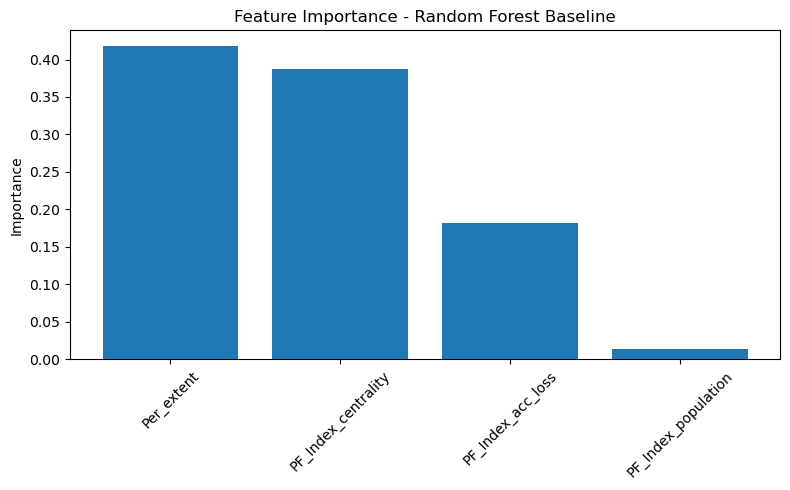

In [855]:
# 8）看特征重要性

feature_importance = pd.DataFrame({
    "feature": X_train_simple_pf_ms.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest Baseline")
plt.tight_layout()
plt.show()

1. Use PF_Index_Risk_equal > 0.25 to identify the high-risk street pool.
2. Use a stricter subset to generate clearer rule-based causal labels.
3. Exclude ambiguous mixed_review samples in the first supervised learning baseline.
4. Train a random forest classifier on simplified HEV-related indicators.
5. Predict the dominant intervention type for the broader high-risk street set.

3.2 训练干预类型模型
